## Bike Rental Demand Prediction using Machine Learning
📌 Project Overview

This project predicts bike rental demand using historical weather and rental data. Multiple regression algorithms were trained and compared to identify the best-performing predictive model.

🎯 Objective

Predict the number of rented bikes using weather conditions, seasonal information, and environmental factors.

Target Variable:

rented_bikes_count

In [1]:
## Most Important
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Model Selection
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Metrics
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score

## Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder , MinMaxScaler


## Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
import xgboost

import missingno as msno
import warnings
warnings.filterwarnings('ignore')

### Load the Data and Look at the big picture

In [2]:
df_Bikes = pd.read_csv('/kaggle/input/datasets/ghadaelfeki/bikes-project-gh/Bikes-Dataset.csv')

Step 3: Display the Data
df.head()

df.shape
df.columns
df.info()

In [3]:
## show the head of the DF
df_Bikes.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit
0,1/1/2011 0:00,Spring,0.0,0.0,Clear,9.84,81.0,NaN,3,13,16,218.729224
1,1/1/2011 1:00,Spring,0.0,0.0,NaN,9.02,80.0,0.0,8,32,40,549.829224
2,1/1/2011 2:00,Spring,0.0,0.0,Clear,9.02,NaN,0.0,5,27,32,433.729224
3,1/1/2011 3:00,Spring,0.0,0.0,Clear,9.84,75.0,0.0,3,10,13,180.029224
4,1/1/2011 4:00,NaN,0.0,0.0,Clear,NaN,75.0,NaN,0,1,1,12.329224


In [4]:
df_Bikes.tail()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit
10881,12/19/2012 19:00,Winter,0.0,1.0,Clear,15.58,50.0,26.0027,7,329,336,4363.929224
10882,12/19/2012 20:00,Winter,0.0,1.0,NaN,14.76,NaN,NaN,10,231,241,3151.329224
10883,12/19/2012 21:00,NaN,0.0,1.0,Clear,13.94,61.0,15.0013,4,164,168,2183.829224
10884,12/19/2012 22:00,Winter,NaN,1.0,Clear,13.94,NaN,6.0032,12,117,129,1715.129224
10885,12/19/2012 23:00,Winter,0.0,1.0,Clear,13.12,66.0,8.9981,4,84,88,1151.829224


In [5]:
df_Bikes.sample(5)

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit
7988,6/13/2012 5:00,Summer,0.0,1.0,Clear,24.60,83.0,12.9980,2,38,40,524.029224
3616,9/1/2011 14:00,Fall,0.0,1.0,Rainy,29.52,NaN,16.9979,54,144,198,2785.829224
8519,7/16/2012 8:00,Fall,0.0,1.0,Clear,30.34,66.0,7.0015,48,619,667,8810.129224
5938,2/3/2012 15:00,Spring,0.0,1.0,NaN,15.58,40.0,0.0000,48,168,216,2992.229224
3034,7/15/2011 8:00,Fall,0.0,1.0,Clear,26.24,65.0,16.9979,50,514,564,7490.029224


In [6]:
df_Bikes.shape

(10886, 12)

In [7]:
df_Bikes.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'humidity', 'windspeed', 'casual', 'registered', 'rented_bikes_count',
       'profit'],
      dtype='object')

In [8]:
## check the nulls
df_Bikes.isna().sum().sort_values(ascending = False)

windspeed             4066
humidity              3424
temp                  2782
weather               2140
workingday            1498
holiday                856
season                 214
datetime                 0
casual                   0
registered               0
rented_bikes_count       0
profit                   0
dtype: int64

In [9]:
missing_data = df_Bikes.isnull().sum().reset_index()
missing_data.columns = ['Column', 'Missing Values']
fig = px.bar(missing_data, x='Column', y='Missing Values', title='Missing Values per Column')
fig.show()

<Axes: >

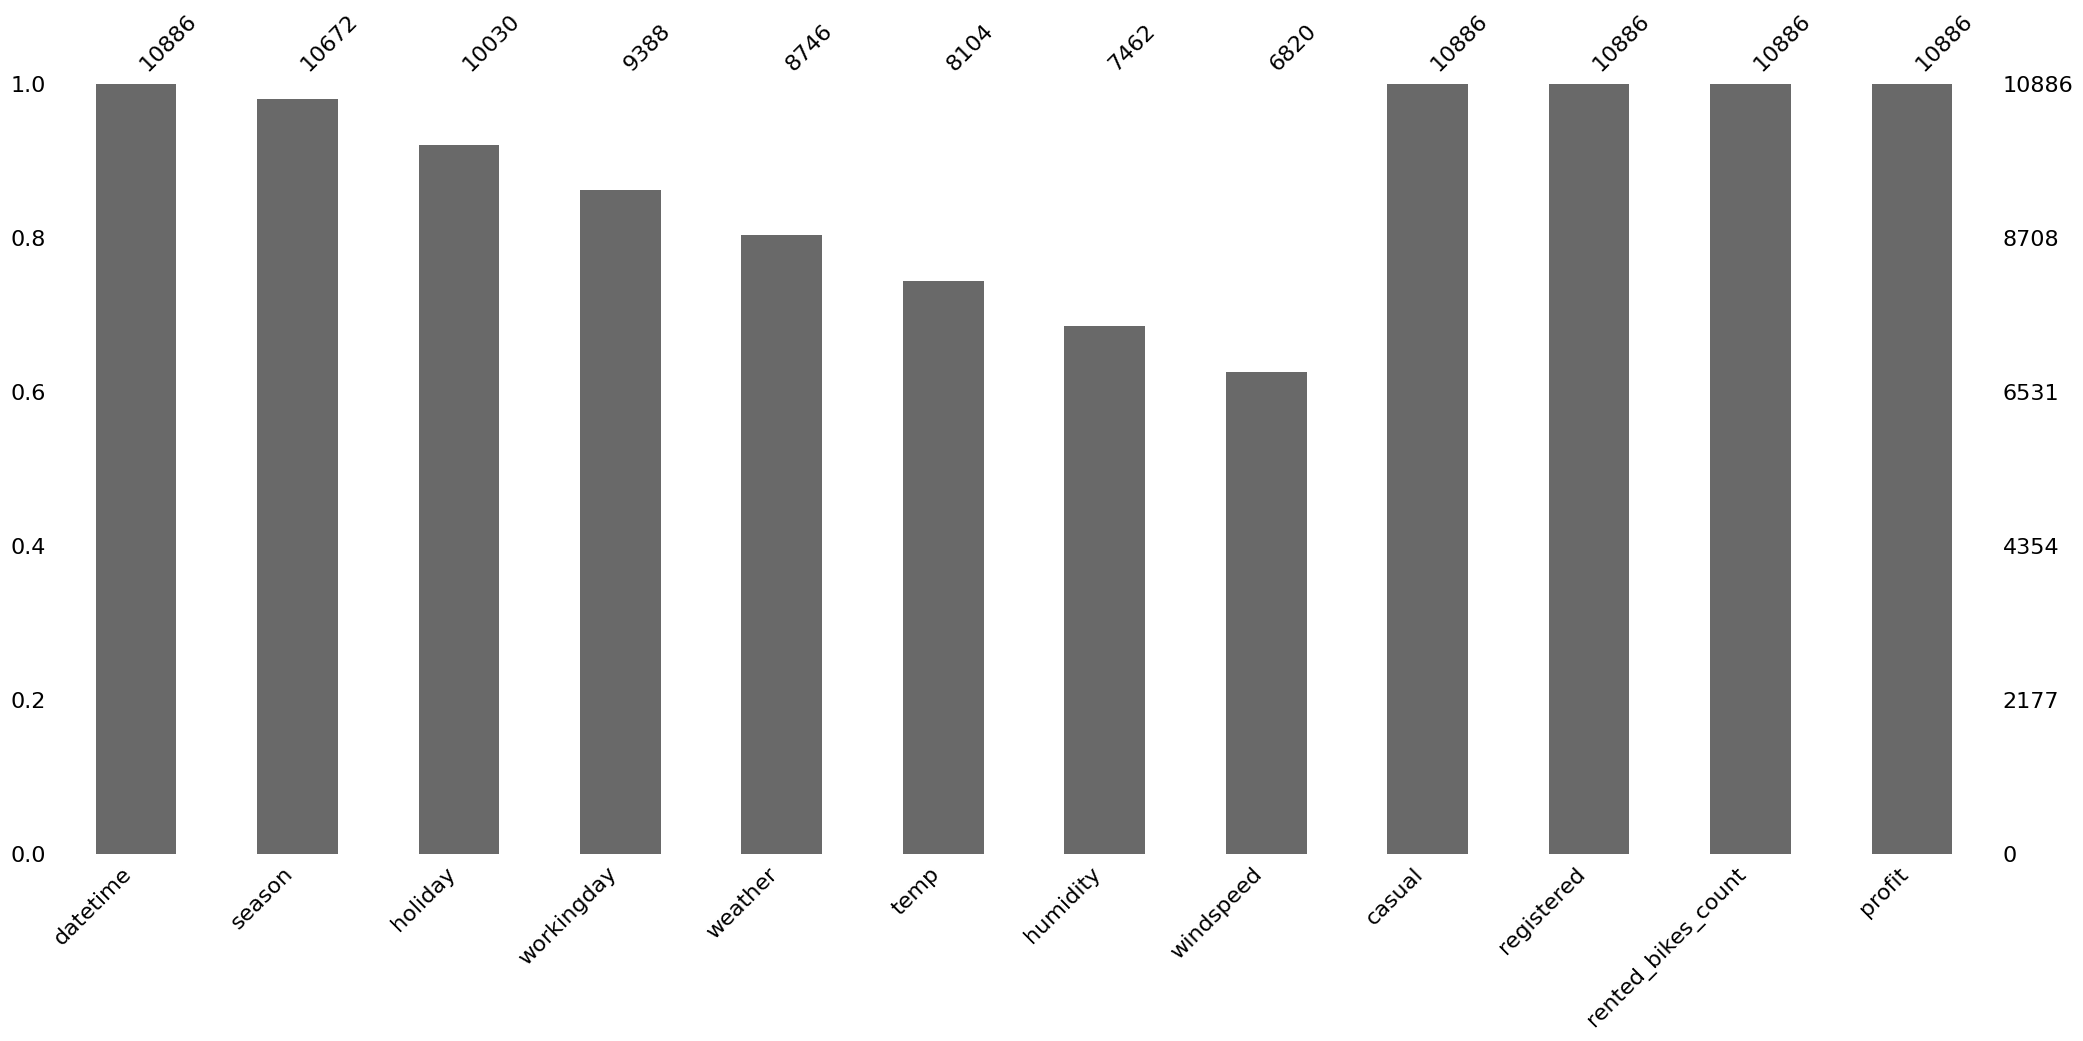

In [10]:
msno.bar(df_Bikes) # bar chart for null values

In [11]:
df_Bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   datetime            10886 non-null  object 
 1   season              10672 non-null  object 
 2   holiday             10030 non-null  float64
 3   workingday          9388 non-null   float64
 4   weather             8746 non-null   object 
 5   temp                8104 non-null   float64
 6   humidity            7462 non-null   float64
 7   windspeed           6820 non-null   float64
 8   casual              10886 non-null  int64  
 9   registered          10886 non-null  int64  
 10  rented_bikes_count  10886 non-null  int64  
 11  profit              10886 non-null  float64
dtypes: float64(6), int64(3), object(3)
memory usage: 1020.7+ KB


In [12]:
df_Bikes.describe(include = "object")

,datetime,season,weather
count,10886,10672,8746
unique,10886,4,4
top,12/19/2012 23:00,Winter,Clear
freq,1,2688,5793


In [13]:
df_Bikes.describe()

,holiday,workingday,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit
count,10030.000000,9388.000000,8104.000000,7462.000000,6820.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,0.029113,0.678206,20.317665,61.790673,12.708806,36.021955,155.552177,191.574132,2625.629931
std,0.168131,0.467189,7.818568,19.262084,8.131154,49.960477,151.039033,181.144454,2489.939816
min,0.000000,0.000000,0.820000,0.000000,0.000000,0.000000,0.000000,1.000000,12.329224
25%,0.000000,0.000000,13.940000,47.000000,7.001500,4.000000,36.000000,42.000000,571.329224
50%,0.000000,1.000000,20.500000,62.000000,12.998000,17.000000,118.000000,145.000000,1977.429224
75%,0.000000,1.000000,26.240000,77.000000,16.997900,49.000000,222.000000,284.000000,3912.429224
max,1.000000,1.000000,41.000000,100.000000,56.996900,367.000000,886.000000,977.000000,13234.829220


In [14]:
#Gradient background color for the numerical columns
df_Bikes.head(10).style.background_gradient(cmap='viridis')

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit
0,1/1/2011 0:00,Spring,0.000000,0.000000,Clear,9.840000,81.000000,nan,3,13,16,218.729224
1,1/1/2011 1:00,Spring,0.000000,0.000000,nan,9.020000,80.000000,0.000000,8,32,40,549.829224
2,1/1/2011 2:00,Spring,0.000000,0.000000,Clear,9.020000,nan,0.000000,5,27,32,433.729224
3,1/1/2011 3:00,Spring,0.000000,0.000000,Clear,9.840000,75.000000,0.000000,3,10,13,180.029224
4,1/1/2011 4:00,nan,0.000000,0.000000,Clear,nan,75.000000,nan,0,1,1,12.329224
5,1/1/2011 5:00,nan,0.000000,nan,Mist,9.840000,nan,6.003200,0,1,1,12.329224
6,1/1/2011 6:00,Spring,0.000000,0.000000,Clear,nan,nan,0.000000,2,0,2,33.829224
7,1/1/2011 7:00,Spring,0.000000,0.000000,Clear,8.200000,nan,nan,1,2,3,42.429224
8,1/1/2011 8:00,Spring,0.000000,0.000000,nan,9.840000,nan,0.000000,1,7,8,106.929224
9,1/1/2011 9:00,Spring,0.000000,0.000000,Clear,nan,76.000000,0.000000,8,6,14,214.429224


In [15]:
## some statistics of the DF --> target column is (median_Bikes_value)
df_Bikes.describe().T.style.background_gradient(cmap='viridis')

,count,mean,std,min,25%,50%,75%,max
holiday,10030.000000,0.029113,0.168131,0.000000,0.000000,0.000000,0.000000,1.000000
workingday,9388.000000,0.678206,0.467189,0.000000,0.000000,1.000000,1.000000,1.000000
temp,8104.000000,20.317665,7.818568,0.820000,13.940000,20.500000,26.240000,41.000000
humidity,7462.000000,61.790673,19.262084,0.000000,47.000000,62.000000,77.000000,100.000000
windspeed,6820.000000,12.708806,8.131154,0.000000,7.001500,12.998000,16.997900,56.996900
casual,10886.000000,36.021955,49.960477,0.000000,4.000000,17.000000,49.000000,367.000000
registered,10886.000000,155.552177,151.039033,0.000000,36.000000,118.000000,222.000000,886.000000
rented_bikes_count,10886.000000,191.574132,181.144454,1.000000,42.000000,145.000000,284.000000,977.000000
profit,10886.000000,2625.629931,2489.939816,12.329224,571.329224,1977.429224,3912.429224,13234.829220


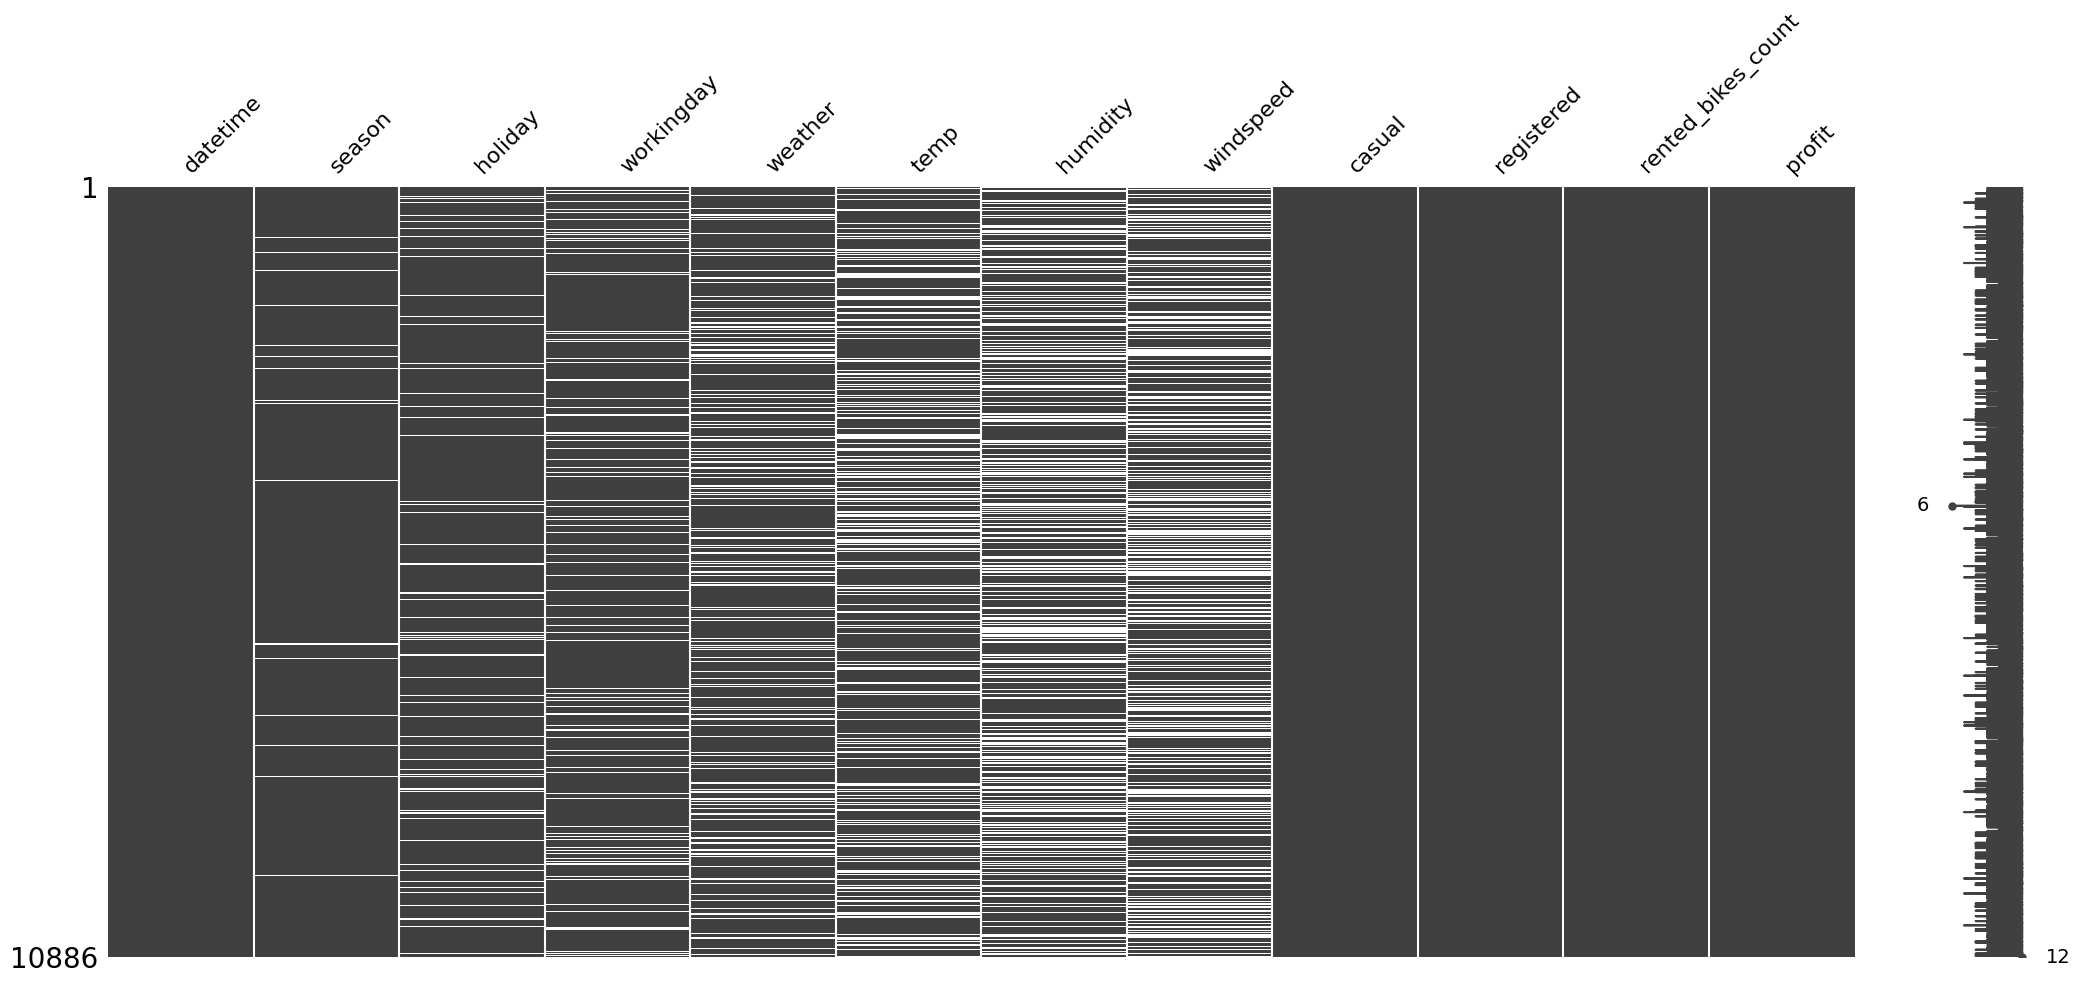

In [16]:

msno.matrix(df_Bikes)
plt.show()

* > `Comment: It seems that Dataset is a contains 10886  instances and winds peed             4066 and 3424 null values in total_humidity ,782 null values in total_temp 2140 null values in total_weather, 1498 null values in total_workingday, 856 null values in total_holiday and  214 null values in total_season and also all datatypes is float64 as they are continuous numerical features except the (season) and (weather) columns which are nominal categorical Feature`

In [17]:
df_Bikes.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis (EDA)

### `Univariate Visualization`

In [18]:
season_values = df_Bikes['season'].unique()
season_values

array(['Spring', nan, 'Summer', 'Fall', 'Winter'], dtype=object)

In [19]:
raplicates = df_Bikes['season'].value_counts()
raplicates # TRY

season
Winter    2688
Fall      2680
Summer    2670
Spring    2634
Name: count, dtype: int64

<Axes: xlabel='season', ylabel='count'>

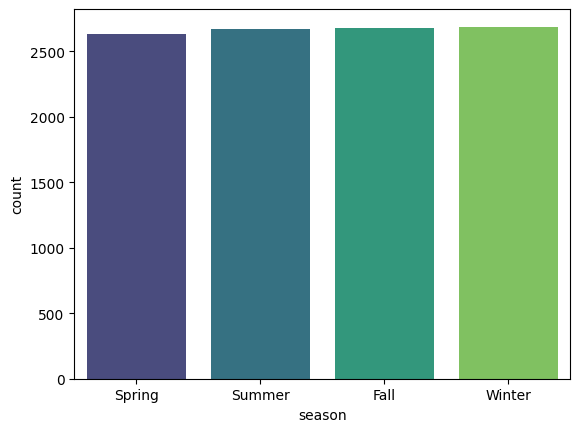

In [20]:
sns.countplot(x='season', data=df_Bikes, palette='viridis')

categories of (season) --- 
 season
Winter    2688
Fall      2680
Summer    2670
Spring    2634
Name: count, dtype: int64
********************************************************************************


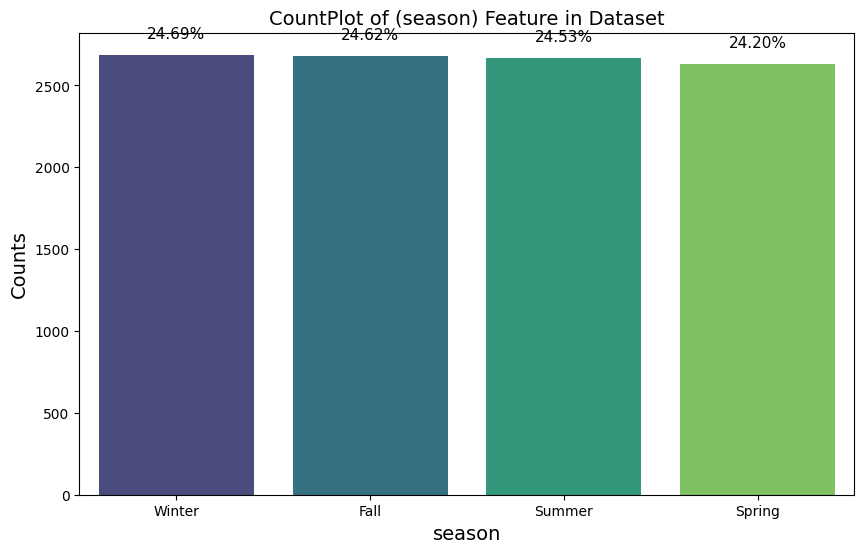

In [21]:
## Check the Distribution of (season) Feature in Dataset
season_values = df_Bikes['season'].value_counts()
print('categories of (season) --- \n', season_values)
print('**'*40)

## plotting

plt.figure(figsize=(10, 6))
sns.countplot(x='season', data=df_Bikes, order=season_values.index, palette='viridis')  ## ordered
plt.title('CountPlot of (season) Feature in Dataset', fontsize=14, c='k')
plt.xlabel('season', fontsize=14, c='k')
plt.ylabel('Counts', fontsize=14, c='k')

## showing the percenatge
for i in range(season_values.shape[0]):
    count = season_values.values[i]
    strt='{:0.2f}%'.format(100*count / df_Bikes.shape[0])


    plt.text(i, count+100, strt, ha='center', color='black', fontsize=11)

### `Visualizing Distribution`

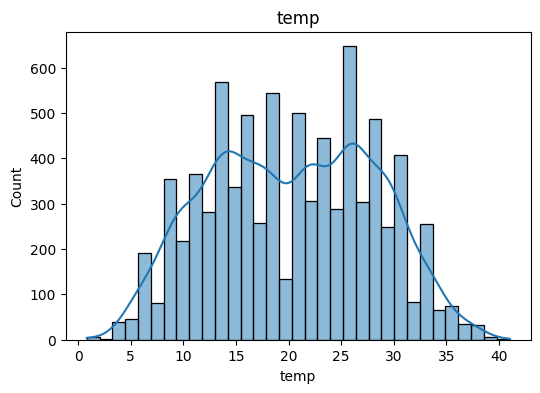

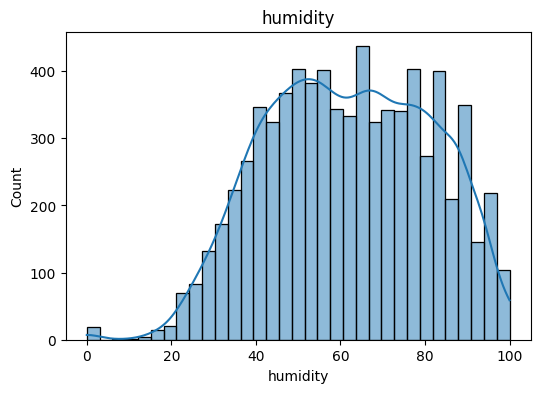

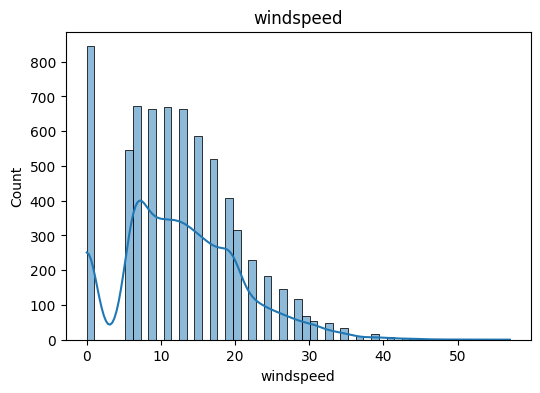

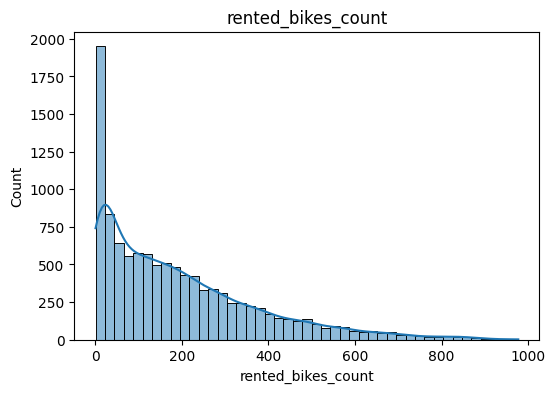

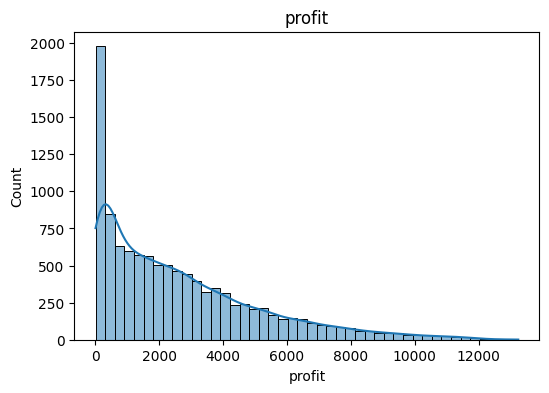

In [22]:
numerical_cols = [
    'temp',
    'humidity',
    'windspeed',
    'rented_bikes_count',
    'profit'
]

for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df_Bikes[col], kde=True)

    plt.title(col)

    plt.show()

### `Check the Correlation between the Features and the Target` (rented_bikes_count)

In [23]:
#df_Bikes.corr()
df_Bikes.corr(numeric_only = True)

,holiday,workingday,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit
holiday,1.000000,-0.249189,-0.001047,0.016190,0.010463,0.042519,-0.021017,-0.005827,-0.001811
workingday,-0.249189,1.000000,0.018954,-0.019167,0.020668,-0.318348,0.118612,0.010940,-0.017230
temp,-0.001047,0.018954,1.000000,-0.068240,-0.025425,0.466035,0.315430,0.391867,0.408043
humidity,0.016190,-0.019167,-0.068240,1.000000,-0.312628,-0.344939,-0.266432,-0.317282,-0.327481
windspeed,0.010463,0.020668,-0.025425,-0.312628,1.000000,0.085055,0.089105,0.097747,0.099102
casual,0.042519,-0.318348,0.466035,-0.344939,0.085055,1.000000,0.497250,0.690414,0.734220
registered,-0.021017,0.118612,0.315430,-0.266432,0.089105,0.497250,1.000000,0.970948,0.954120
rented_bikes_count,-0.005827,0.010940,0.391867,-0.317282,0.097747,0.690414,0.970948,1.000000,0.998050
profit,-0.001811,-0.017230,0.408043,-0.327481,0.099102,0.734220,0.954120,0.998050,1.000000


In [24]:
## Correlatio (pearson correlation)
df_Bikes.corr(numeric_only = True)['rented_bikes_count'].sort_values(ascending=False)

rented_bikes_count    1.000000
profit                0.998050
registered            0.970948
casual                0.690414
temp                  0.391867
windspeed             0.097747
workingday            0.010940
holiday              -0.005827
humidity             -0.317282
Name: rented_bikes_count, dtype: float64

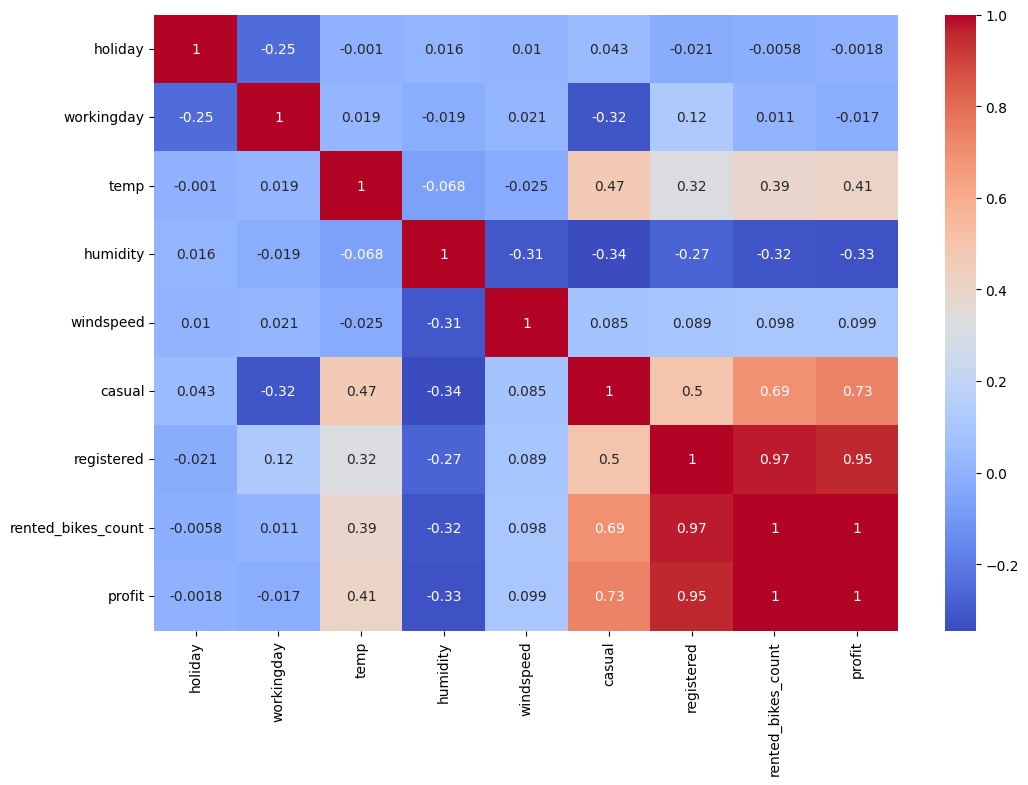

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(df_Bikes.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()


* > `Comment: registered → very strong positive correlation (but don't use it because it causes data leakage).
casual → very strong positive correlation (also don't use it).
temp → useful feature.
humidity → moderate negative relationship.
windspeed → weak relationship.

In [26]:
Bikes_corr = df_Bikes.corr(numeric_only = True)[["temp" , "rented_bikes_count"]]
Bikes_corr

,temp,rented_bikes_count
holiday,-0.001047,-0.005827
workingday,0.018954,0.010940
temp,1.000000,0.391867
humidity,-0.068240,-0.317282
windspeed,-0.025425,0.097747
casual,0.466035,0.690414
registered,0.315430,0.970948
rented_bikes_count,0.391867,1.000000
profit,0.408043,0.998050


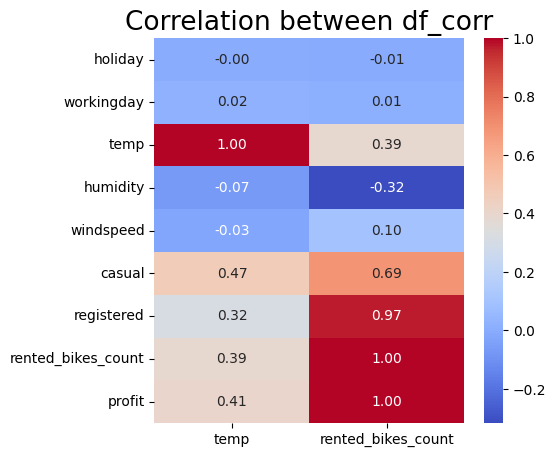

In [27]:
plt.figure(figsize = (5,5))
sns.heatmap(Bikes_corr , annot = True , fmt = ".2f" , cmap = "coolwarm")
plt.title("Correlation between df_corr" , fontsize = 19 , c = "k")
plt.show()

### `Bivariate Visualization`
###### two

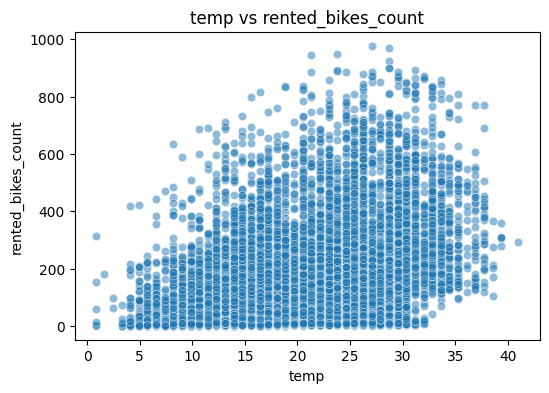

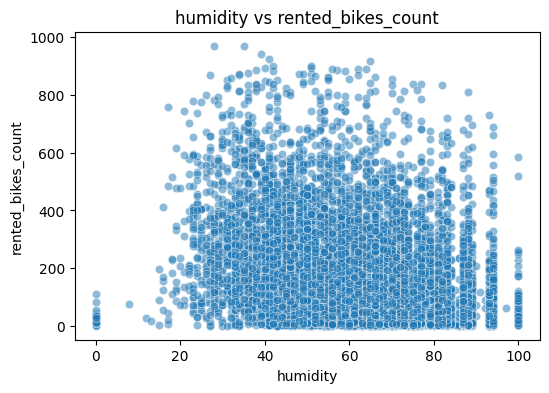

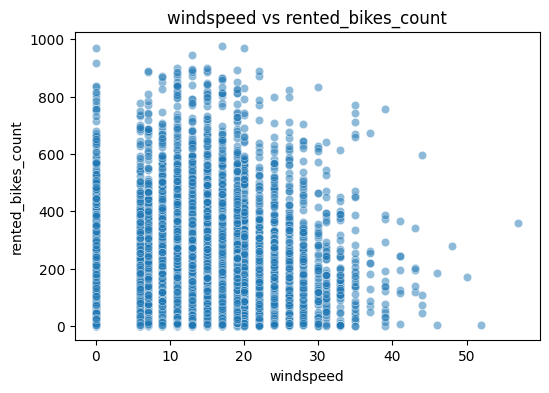

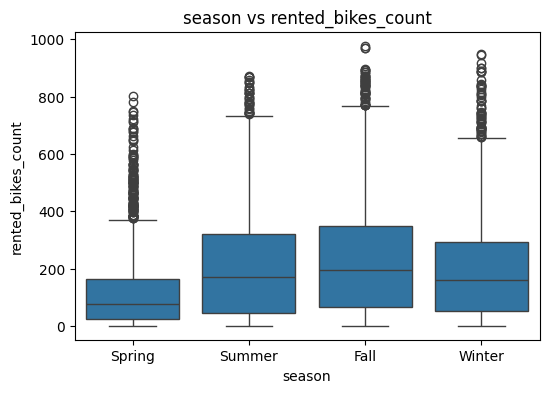

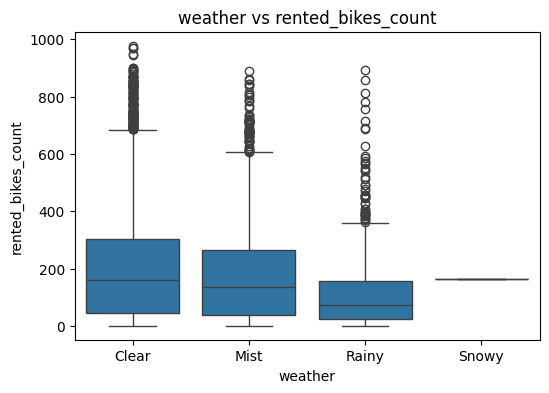

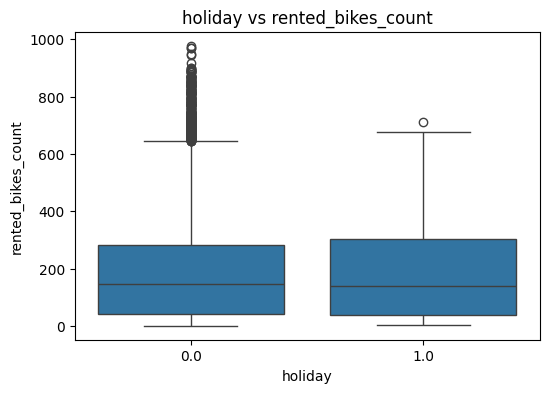

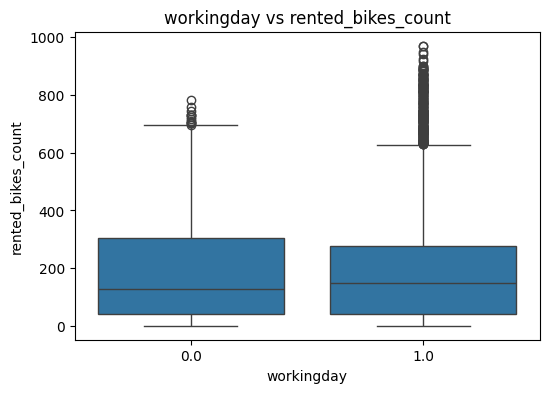

In [28]:
# Target variable
target = 'rented_bikes_count'

# Numerical features
numerical_features = ['temp', 'humidity', 'windspeed']

# Categorical features
categorical_features = ['season', 'weather', 'holiday', 'workingday']

# Scatter plots for numerical features
for feature in numerical_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df_Bikes, x=feature, y=target, alpha=0.5)
    plt.title(f'{feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.show()

# Box plots for categorical features
for feature in categorical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df_Bikes, x=feature, y=target)
    plt.title(f'{feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.show()

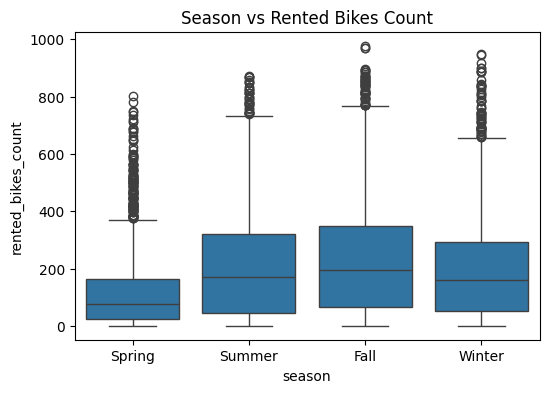

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x='season', y='rented_bikes_count', data=df_Bikes)
plt.title("Season vs Rented Bikes Count")
plt.show()

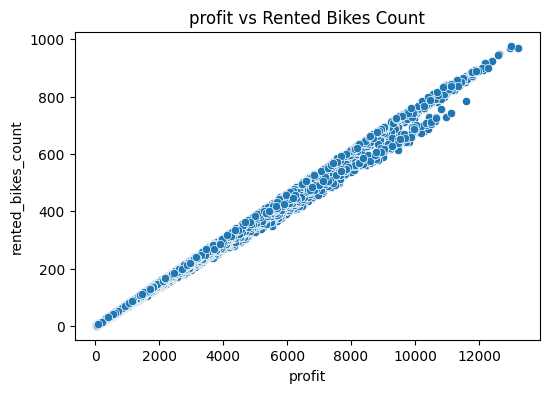

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='profit', y='rented_bikes_count', data=df_Bikes)
plt.title("profit vs Rented Bikes Count")
plt.show()

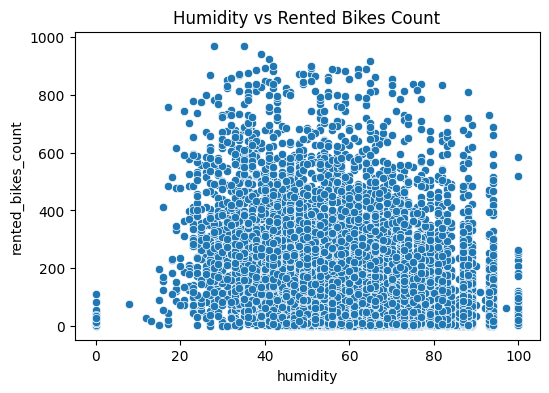

In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='humidity', y='rented_bikes_count', data=df_Bikes)
plt.title("Humidity vs Rented Bikes Count")
plt.show()

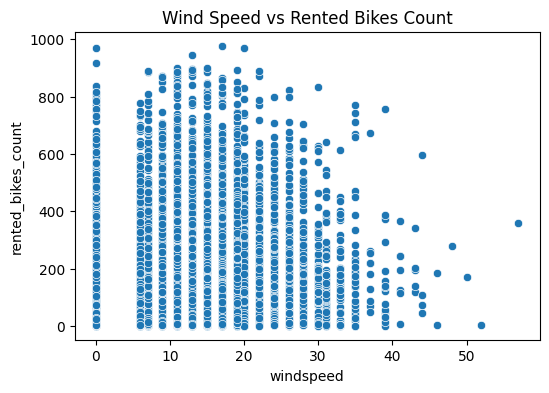

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='windspeed', y='rented_bikes_count', data=df_Bikes)
plt.title("Wind Speed vs Rented Bikes Count")
plt.show()

In [33]:
df_Bikes['rented_bikes_count'].describe()

count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: rented_bikes_count, dtype: float64

# `Preprocessing Data`

### `Categorical Features`
`Categorical Features should be encoed before being passed to the Model, there are more than one type of encoding`
* `Label Encoding: mapping categories to numbers start from 0 to the length of categories and map these values in one column`
* `Ordinal Encoding: mapping ordinal categories start from 0 to the length of categories but orderd 0<1<2 ...`
* `OHE = One Hot Encoding: mapped to multiple columns, column for each category, each column contains ones when this category is mentioned`

In [34]:
#### convert Categorical to numeric

Encoder = LabelEncoder()
df_Bikes["season"] = Encoder.fit_transform(df_Bikes["season"])
df_Bikes["weather"] = Encoder.fit_transform(df_Bikes["weather"])
df_Bikes["holiday"] = Encoder.fit_transform(df_Bikes["holiday"])
df_Bikes["workingday"] = Encoder.fit_transform(df_Bikes["workingday"])


In [35]:
df_Bikes["datetime"] = pd.to_datetime(df_Bikes["datetime"])

df_Bikes["year"] = df_Bikes["datetime"].dt.year

df_Bikes["month"] = df_Bikes["datetime"].dt.month

df_Bikes["day"] = df_Bikes["datetime"].dt.day

df_Bikes["hour"] = df_Bikes["datetime"].dt.hour

df_Bikes.drop("datetime", axis=1, inplace=True)

In [36]:
df_Bikes.head(10)

,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit,year,month,day,hour
0,1,0,0,0,9.84,81.0,NaN,3,13,16,218.729224,2011,1,1,0
1,1,0,0,4,9.02,80.0,0.0000,8,32,40,549.829224,2011,1,1,1
2,1,0,0,0,9.02,NaN,0.0000,5,27,32,433.729224,2011,1,1,2
3,1,0,0,0,9.84,75.0,0.0000,3,10,13,180.029224,2011,1,1,3
4,4,0,0,0,NaN,75.0,NaN,0,1,1,12.329224,2011,1,1,4
5,4,0,2,1,9.84,NaN,6.0032,0,1,1,12.329224,2011,1,1,5
6,1,0,0,0,NaN,NaN,0.0000,2,0,2,33.829224,2011,1,1,6
7,1,0,0,0,8.20,NaN,NaN,1,2,3,42.429224,2011,1,1,7
8,1,0,0,4,9.84,NaN,0.0000,1,7,8,106.929224,2011,1,1,8
9,1,0,0,0,NaN,76.0,0.0000,8,6,14,214.429224,2011,1,1,9


In [37]:
df_Bikes.tail(10)

,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit,year,month,day,hour
10876,3,0,1,0,NaN,NaN,NaN,33,185,218,2953.529224,2012,12,19,14
10877,3,2,1,0,NaN,50.0,19.0012,28,209,237,3177.129224,2012,12,19,15
10878,3,0,1,0,NaN,50.0,NaN,37,297,334,4467.129224,2012,12,19,16
10879,3,0,2,0,NaN,50.0,26.0027,26,536,562,7361.029224,2012,12,19,17
10880,3,0,1,4,15.58,NaN,23.9994,23,546,569,7438.429224,2012,12,19,18
10881,3,0,1,0,15.58,50.0,26.0027,7,329,336,4363.929224,2012,12,19,19
10882,3,0,1,4,14.76,NaN,NaN,10,231,241,3151.329224,2012,12,19,20
10883,4,0,1,0,13.94,61.0,15.0013,4,164,168,2183.829224,2012,12,19,21
10884,3,2,1,0,13.94,NaN,6.0032,12,117,129,1715.129224,2012,12,19,22
10885,3,0,1,0,13.12,66.0,8.9981,4,84,88,1151.829224,2012,12,19,23


In [38]:
df_Bikes.sample(10)

,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit,year,month,day,hour
2486,2,0,0,0,32.80,55.0,NaN,112,235,347,4957.329224,2011,6,11,12
3322,0,0,2,0,30.34,58.0,22.0028,29,320,349,4626.229224,2011,8,8,8
3052,0,0,0,0,24.60,NaN,8.9981,10,48,58,790.629224,2011,7,16,2
7429,2,0,1,2,24.60,78.0,16.9979,13,134,147,1951.629224,2012,5,8,22
2546,2,0,1,0,NaN,49.0,12.9980,13,18,31,455.229224,2011,6,14,0
10208,3,0,0,0,18.04,54.0,8.9981,103,256,359,5073.429224,2012,11,10,18
3265,0,0,2,0,27.88,NaN,NaN,37,102,139,1951.629224,2011,8,5,23
115,1,0,1,0,7.38,NaN,0.0000,0,11,11,141.329224,2011,1,6,0
2121,2,0,0,1,NaN,100.0,8.9981,4,38,42,558.429224,2011,5,15,7
4477,3,0,1,1,25.42,NaN,11.0014,32,137,169,2317.129224,2011,10,18,14


In [39]:
'''
X_cat = X.select_dtypes(object)
X_cat
cat_encoder = OneHotEncoder()
ocat_1hot = cat_encoder.fit_transform(X_cat)
housing_cat_1hot
'''

'\nX_cat = X.select_dtypes(object)\nX_cat\ncat_encoder = OneHotEncoder()\nocat_1hot = cat_encoder.fit_transform(X_cat)\nhousing_cat_1hot\n'

### `Feature Engineering`
`Try to add some features, thinking that it will be more useful and more correlated to the target`

In [40]:
df_Bikes['temp_windspeed'] = df_Bikes['temp'] * df_Bikes['windspeed']

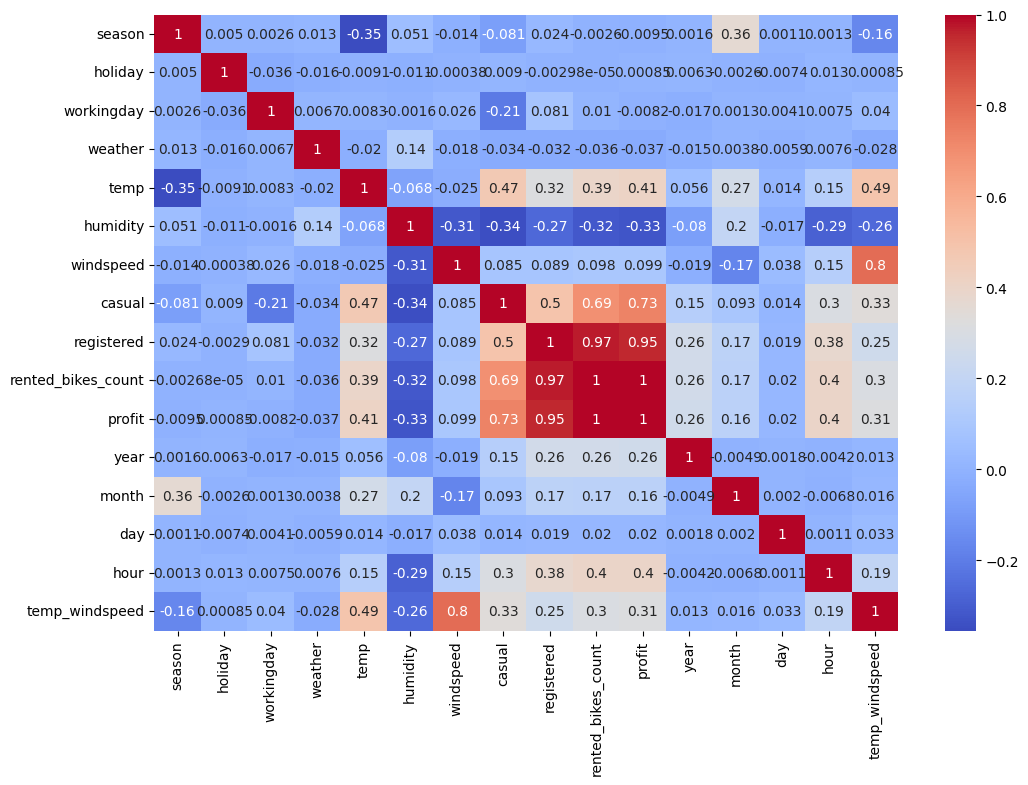

In [41]:
plt.figure(figsize=(12,8))
sns.heatmap(df_Bikes.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

### `Dealing with nulls` Data Cleaning


In [42]:
## I choose to impute the nulls with median --> using SimpleImputer
Imputer = SimpleImputer(strategy = "median") ## define an instance
df_imputed = Imputer.fit_transform(df_Bikes)

In [43]:
df_imputed = pd.DataFrame(df_imputed , columns = df_Bikes.columns)

In [44]:
df_imputed.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit,year,month,day,hour,temp_windspeed
0,1.0,0.0,0.0,0.0,9.84,81.0,12.998,3.0,13.0,16.0,218.729224,2011.0,1.0,1.0,0.0,223.419004
1,1.0,0.0,0.0,4.0,9.02,80.0,0.000,8.0,32.0,40.0,549.829224,2011.0,1.0,1.0,1.0,0.000000
2,1.0,0.0,0.0,0.0,9.02,62.0,0.000,5.0,27.0,32.0,433.729224,2011.0,1.0,1.0,2.0,0.000000
3,1.0,0.0,0.0,0.0,9.84,75.0,0.000,3.0,10.0,13.0,180.029224,2011.0,1.0,1.0,3.0,0.000000
4,4.0,0.0,0.0,0.0,20.50,75.0,12.998,0.0,1.0,1.0,12.329224,2011.0,1.0,1.0,4.0,223.419004


In [45]:
df_imputed.isna().sum()

season                0
holiday               0
workingday            0
weather               0
temp                  0
humidity              0
windspeed             0
casual                0
registered            0
rented_bikes_count    0
profit                0
year                  0
month                 0
day                   0
hour                  0
temp_windspeed        0
dtype: int64

In [46]:
df_Bikes.isna().sum()

season                   0
holiday                  0
workingday               0
weather                  0
temp                  2782
humidity              3424
windspeed             4066
casual                   0
registered               0
rented_bikes_count       0
profit                   0
year                     0
month                    0
day                      0
hour                     0
temp_windspeed        5766
dtype: int64

In [47]:
median = df_Bikes.median()
df_Bikes.fillna(median, inplace=True)

In [48]:
df_Bikes.isna().sum()

season                0
holiday               0
workingday            0
weather               0
temp                  0
humidity              0
windspeed             0
casual                0
registered            0
rented_bikes_count    0
profit                0
year                  0
month                 0
day                   0
hour                  0
temp_windspeed        0
dtype: int64

### `Dealing Outliers` Data Cleaning


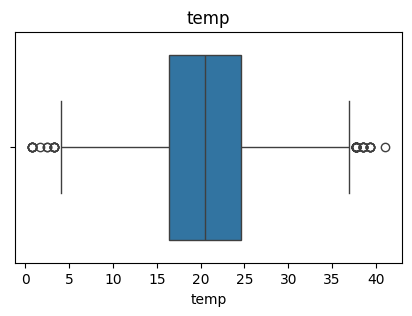

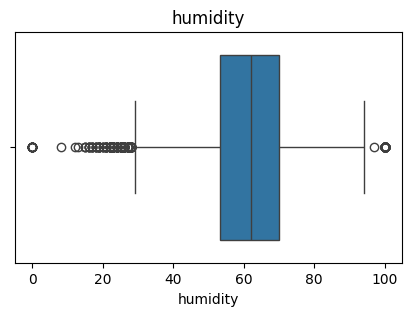

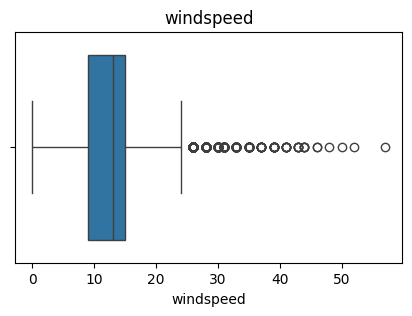

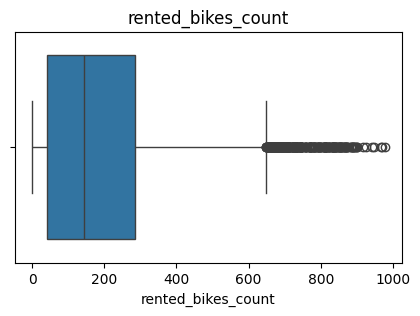

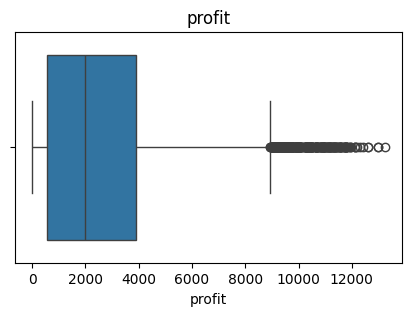

In [49]:
for col in numerical_cols:

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df_Bikes[col])

    plt.title(col)

    plt.show()

In [50]:
numeric_cols = df_Bikes.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df_Bikes[col].quantile(0.25)
    Q3 = df_Bikes[col].quantile(0.75)
    IQR = Q3 - Q1
    median = df_Bikes[col].median()

    df_Bikes[col] = df_Bikes[col].apply(lambda x: median if x < (Q1 - 1.5*IQR) or x > (Q3 + 1.5*IQR) else x)

df_Bikes.head()


,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,profit,year,month,day,hour,temp_windspeed
0,1,0.0,0,0,9.84,81.0,12.998,3.0,13.0,16.0,218.729224,2011,1,1,0,223.419004
1,1,0.0,0,4,9.02,80.0,0.000,8.0,32.0,40.0,549.829224,2011,1,1,1,223.419004
2,1,0.0,0,0,9.02,62.0,0.000,5.0,27.0,32.0,433.729224,2011,1,1,2,223.419004
3,1,0.0,0,0,9.84,75.0,0.000,3.0,10.0,13.0,180.029224,2011,1,1,3,223.419004
4,4,0.0,0,0,20.50,75.0,12.998,0.0,1.0,1.0,12.329224,2011,1,1,4,223.419004


### `Split the Dataset`


In [51]:
## Split the Whole dataset to features and target

X = df_imputed.drop(columns=['rented_bikes_count'], axis=1)  ## features

y = df_imputed['rented_bikes_count']  ## target

In [52]:
X.shape

(10886, 15)

In [53]:
y.shape

(10886,)

In [54]:
X.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,profit,year,month,day,hour,temp_windspeed
0,1.0,0.0,0.0,0.0,9.84,81.0,12.998,3.0,13.0,218.729224,2011.0,1.0,1.0,0.0,223.419004
1,1.0,0.0,0.0,4.0,9.02,80.0,0.000,8.0,32.0,549.829224,2011.0,1.0,1.0,1.0,0.000000
2,1.0,0.0,0.0,0.0,9.02,62.0,0.000,5.0,27.0,433.729224,2011.0,1.0,1.0,2.0,0.000000
3,1.0,0.0,0.0,0.0,9.84,75.0,0.000,3.0,10.0,180.029224,2011.0,1.0,1.0,3.0,0.000000
4,4.0,0.0,0.0,0.0,20.50,75.0,12.998,0.0,1.0,12.329224,2011.0,1.0,1.0,4.0,223.419004


In [55]:
y.head()

0    16.0
1    40.0
2    32.0
3    13.0
4     1.0
Name: rented_bikes_count, dtype: float64

# Train Test Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

## check shape
print('X_train shape -- ', X_train.shape)
print('y_train shape -- ', y_train.shape)

print('X_test shape -- ', X_test.shape)
print('y_test shape -- ', y_test.shape)

X_train shape --  (8708, 15)
y_train shape --  (8708,)
X_test shape --  (2178, 15)
y_test shape --  (2178,)


### `Standardize the Dataset`

# StandardScaler

In [57]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
X_train_scaled

array([[-1.33593732, -0.33032967,  0.21958261, ..., -0.72446602,
        -0.94596221, -0.11297351],
       [-1.33593732, -0.33032967, -1.36988152, ..., -1.09040761,
         0.64321714, -0.11297351],
       [-1.33593732, -0.33032967,  0.21958261, ...,  0.19038796,
         0.49874629, -0.11297351],
       ...,
       [ 1.2471451 , -0.33032967,  1.80904673, ...,  1.47118354,
         0.64321714, -0.11297351],
       [-0.47490985, -0.33032967, -1.36988152, ...,  1.65415434,
        -0.65702051,  2.25769717],
       [ 0.38611762, -0.33032967,  0.21958261, ..., -1.45634921,
        -0.65702051, -0.11297351]])

In [59]:
X_test_scaled

array([[-1.33593732, -0.33032967,  0.21958261, ...,  1.65415434,
        -0.07913711, -0.11297351],
       [-0.47490985,  1.48679653,  1.80904673, ...,  1.10524195,
        -0.80149136, -0.11297351],
       [ 1.2471451 , -0.33032967, -1.36988152, ...,  0.19038796,
         0.93215884, -0.11297351],
       ...,
       [ 1.2471451 , -0.33032967, -1.36988152, ..., -1.09040761,
         0.35427544, -0.11297351],
       [-0.47490985, -0.33032967, -1.36988152, ..., -1.63932   ,
        -0.94596221, -1.16644308],
       [ 0.38611762, -0.33032967,  0.21958261, ...,  0.92227115,
         0.20980459, -0.11297351]])

## using StandardScaler for each Feature to be (mean=0, std=1)
## This techniques helps for better training and to converge faster and put all features in the same scale
#scaler = StandardScaler()  ## define an instance

## fit and transform to training data (only Numerical)
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

# MinMaxScaler

In [60]:
'''
scm = MinMaxScaler()
scm.fit(X_train)
X_train_scaled = scm.transform(X_train)
X_test_scaled = scm.transform(X_test)
'''

'\nscm = MinMaxScaler()\nscm.fit(X_train)\nX_train_scaled = scm.transform(X_train)\nX_test_scaled = scm.transform(X_test)\n'

In [61]:
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_train_final

,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,profit,year,month,day,hour,temp_windspeed
0,-1.335937,-0.33033,0.219583,-0.731194,0.017271,0.009623,0.029912,-0.621710,-0.831035,-0.865732,-1.003221,0.138224,-0.724466,-0.945962,-0.112974
1,-1.335937,-0.33033,-1.369882,1.867944,2.444951,0.009623,0.029912,3.229395,0.644580,1.618655,0.996790,0.429385,-1.090408,0.643217,-0.112974
2,-1.335937,-0.33033,0.219583,-0.731194,0.017271,0.009623,0.646642,0.401240,0.426215,0.472414,0.996790,0.138224,0.190388,0.498746,-0.112974
3,0.386118,-0.33033,1.809047,-0.081410,-0.832417,0.009623,-0.894666,-0.661826,-1.016314,-1.024788,-1.003221,-0.735258,0.007417,-1.090433,-0.997312
4,1.247145,-0.33033,-1.369882,-0.731194,0.017271,-1.053491,0.029912,-0.019975,0.062274,0.041925,-1.003221,1.302868,1.654154,-0.223608,-0.112974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8703,-0.474910,-0.33033,-1.369882,-0.731194,0.017271,-0.928419,0.029912,-0.601652,-0.817801,-0.848443,0.996790,-1.608740,0.739300,-1.379375,-0.112974
8704,1.247145,-0.33033,-1.369882,-0.731194,-1.317953,0.009623,0.029912,-0.421132,-0.142856,-0.257170,-1.003221,1.594028,0.007417,-0.368079,-0.112974
8705,1.247145,-0.33033,1.809047,-0.731194,-1.317953,-0.865882,0.029912,-0.180438,0.340193,0.204439,-1.003221,1.594028,1.471184,0.643217,-0.112974
8706,-0.474910,-0.33033,-1.369882,1.867944,-0.711033,-2.804502,3.422441,-0.601652,-0.923674,-0.931429,-1.003221,-1.317579,1.654154,-0.657021,2.257697


In [62]:
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)
X_test_final

,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,profit,year,month,day,hour,temp_windspeed
0,-1.335937,-0.330330,0.219583,-0.731194,1.959415,-0.177985,0.029912,-0.140322,-0.381072,-0.347071,-1.003221,0.138224,1.654154,-0.079137,-0.112974
1,-0.474910,1.486797,1.809047,-0.731194,-2.410410,-0.490666,0.029912,-0.721999,-0.943526,-0.988482,0.996790,-1.608740,1.105242,-0.801491,-0.112974
2,1.247145,-0.330330,-1.369882,1.867944,0.017271,-0.865882,0.029912,-0.481305,-0.030365,-0.189744,-1.003221,1.594028,0.190388,0.932159,-0.112974
3,-1.335937,-0.330330,0.219583,-0.081410,1.352495,0.009623,0.029912,0.682049,0.049040,0.273594,0.996790,0.429385,0.922271,-0.223608,1.067466
4,0.386118,-0.330330,0.219583,-0.731194,0.745575,0.009623,0.646642,0.200661,0.135062,0.175048,0.996790,-0.152936,0.922271,1.654513,1.423815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2173,0.386118,-0.330330,-1.369882,0.568375,0.502807,-0.803346,0.955523,1.404132,0.591643,0.947853,-1.003221,-0.444097,-0.358524,0.787688,1.569357
2174,-0.474910,-0.330330,0.219583,0.568375,-1.075185,0.259768,1.418328,-0.721999,-1.016314,-1.045535,0.996790,-1.608740,1.288213,-1.090433,0.367635
2175,1.247145,-0.330330,-1.369882,1.867944,0.017271,-1.366171,0.029912,2.266619,1.352610,1.841679,0.996790,1.302868,-1.090408,0.354275,-0.112974
2176,-0.474910,-0.330330,-1.369882,-0.731194,-1.317953,1.197809,-0.894666,-0.721999,-0.996462,-1.029975,0.996790,-1.608740,-1.639320,-0.945962,-1.166443


# ` ML Models`



### `LinearRegression`

In [63]:
lr = LinearRegression()
lr.fit(X_train_final, y_train)

LinearRegression()

In [64]:
lr.score(X_train_final, y_train)

1.0

In [65]:
y_pred = lr.predict(X_test_final)

In [66]:
metrics.mean_squared_error(y_test, y_pred)

1.6335937352127625e-26

In [67]:
metrics.mean_absolute_error(y_test, y_pred)

1.0190318133242649e-13

In [68]:
print("Accuracy --> ",metrics.r2_score(y_test, y_pred)*100)

Accuracy -->  100.0


In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 :", r2_score(y_test, y_pred))

MAE : 1.0190318133242649e-13
MSE : 1.6335937352127625e-26
RMSE : 1.2781211739161363e-13
R2 : 1.0


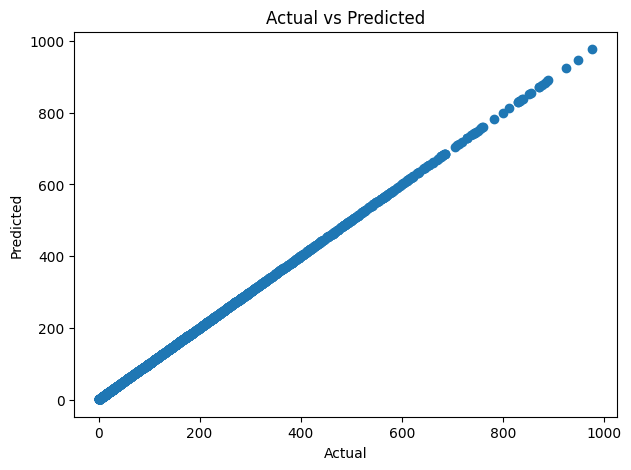

In [70]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

Conclusion:

* The dataset was cleaned by handling missing values.
* The categorical variables were encoded using Label Encoding.
* A Linear Regression model was trained to predict the target variable.
* The model was evaluated using MAE, MSE, RMSE, and R².
* The heatmap was used to identify relationships between variables, while histograms and boxplots helped understand distributions and detect outliers.